# Differential Gene Expression Analysis Report

In [100]:
#| echo: false
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Dataset1= pd.read_csv("/home/mbxhb5/Coursework2526/Coursework_4138/Python_Coursework/Gene_Expression/A_vs_B.deseq2_results.tsv", sep ="\t")
Dataset2 = pd.read_csv("/home/mbxhb5/Coursework2526/Coursework_4138/Python_Coursework/Gene_Expression/A_vs_E.deseq2_results.tsv", sep ="\t")


## Gene Comparison Datasets
### Dataset 1 : Condition B

In [11]:
#| echo: false
Dataset1

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj
0,Q0020,2846.323000,-1.120311,0.419071,1.321372e-04,1.864099e-03
1,Q0045,4965.675000,-0.053066,0.502978,7.991367e-01,8.997256e-01
2,Q0050,97393.600000,-0.914486,0.257698,4.423992e-05,7.927488e-04
3,Q0055,9176.751000,-1.610330,0.293547,2.991002e-11,2.066450e-08
4,Q0060,1104.390000,-1.404737,0.298873,1.213829e-08,1.509518e-06
...,...,...,...,...,...,...
6392,YPR200C,11.660700,-0.628698,0.466583,2.292884e-02,8.466243e-02
6393,YPR201W,6.547552,-0.089403,0.421236,7.330754e-01,8.600496e-01
6394,YPR202W,1.681190,-0.035514,0.532066,8.307187e-01,9.163400e-01
6395,YPR203W,0.983849,-0.016051,0.559882,8.816009e-01,9.438014e-01


### Dataset 2 : Condition E

In [13]:
#| echo: false
Dataset2

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01
...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN


## Summary Statistics
### The Number of Significantly Up and Down Regulated Genes per Dataset

The gene comparisons were filtered for only significantly differentially expressed genes using the p-value threshold (P < 0.05). The log fold change measures the direction and magnitude of the gene expression with positive value indicating upregulation and negative values indcating downregulation. From this, the thresholds were set: for upregulation (log2FC >= 1) and downregulation (log2FC <= -1).

In [88]:
#| echo: false
def signif_gene_number(deseq):
    d = deseq.dropna() #remove NA
    upreg = d.query("pvalue < 0.05 & log2FoldChange >= 1") #filter for genes with significant P value and significant pvalue
    upreg_total = len(upreg.index) #total number of genes that fit parameters
    print(upreg_total, "upregulated genes")
    downreg = d.query("pvalue < 0.05 & log2FoldChange <= -1 ") #filter for genes with negative logFC and significant pvalue
    downreg_total = len(downreg.index) #total number of genes that fit parameters
    print(downreg_total, "downregulated genes")

| Dataset   | Upregulated | Downregulated |
|-----------|-------------|---------------|
|Condition B| 60          | 215           |
|Condition E| 561         | 921           |

: Number of Differentially Expressed Genes {.striped .hover}

## Significant Genes List
### Significanty Upregulated and Downregulated Genes with Their Corrsponding log2FC, P-value and Adjusted P-values

In [102]:
#| echo: false
def signif_gene_list(data1, data2):
    data1["dataset"] = "B"  # Add column identifying dataset origin
    data2["dataset"] = "E"
    comps = pd.concat([data1, data2])  # concatenate new dataframes
    comps_filtered = comps.dropna()  # Remove missing values
    signif_comps = comps_filtered.query("pvalue < 0.05") # Filter for significant pvalue
    signif_upreg = signif_comps.query("log2FoldChange >= 1") #Positive log2FC value for upregulated genes
    signif_downreg = signif_comps.query("log2FoldChange <= -1") # Negative log2FC value for downregulated genes
    signif_reg = pd.concat([signif_upreg, signif_downreg])
    signif_reg.filter(items=["gene_id", "log2FoldChange", "pavlue", "padj", "dataset"])
    display(signif_reg)

signif_gene_list(Dataset1, Dataset2)

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,dataset
403,YBR156C,63.62428,1.065185,0.338480,6.263108e-05,1.024842e-03,B
417,YBR169C,1332.22800,1.171439,0.279093,7.458115e-07,3.685699e-05,B
424,YBR177C,279.34010,1.595021,0.330397,1.114807e-09,1.925520e-07,B
431,YBR184W,27.08348,1.421138,0.319252,3.193761e-08,3.203033e-06,B
494,YBR245C,572.10350,1.125515,0.193517,3.048554e-10,7.020707e-08,B
...,...,...,...,...,...,...,...
6384,YPR191W,31.01317,-1.073127,0.395717,2.118958e-03,6.395706e-03,E
6387,YPR194C,327.46180,-4.302294,0.522719,1.716014e-19,1.686676e-17,E
6389,YPR196W,535.90220,-1.722141,0.309022,1.220809e-09,1.952653e-08,E
6390,YPR198W,143.39460,-2.122686,0.235922,1.977200e-21,2.409812e-19,E


### Statistics Table for the P-values and logFC per Dataset

In [103]:
#| echo: false
def summary(deseq):
    d = deseq.dropna()
    filtered_deseq = d.filter(["pvalue", "log2FoldChange"])
    display(filtered_deseq.describe())

#### Condition B:

In [105]:
#| echo: false
summary(Dataset1)

,pvalue,log2FoldChange
count,6.218000e+03,6218.000000
mean,3.030422e-01,-0.073995
std,3.151676e-01,1.128143
min,9.164259e-16,-25.534050
25%,1.784172e-02,-0.318445
50%,1.787987e-01,-0.019090
75%,5.462145e-01,0.266642
max,1.000000e+00,20.895750


#### Condition E:

In [106]:
#| echo: false
summary(Dataset2)

,pvalue,log2FoldChange
count,6.094000e+03,6094.000000
mean,2.133912e-01,-0.131371
std,2.942642e-01,1.443180
min,3.845847e-219,-24.882900
25%,2.863758e-04,-0.628644
50%,4.142155e-02,-0.032872
75%,3.667528e-01,0.510509
max,1.000000e+00,22.732160


## Plots of Gene Expression

In [76]:
#| echo: false
def volcano_plot(deseq):
    plt.scatter(x=deseq["log2FoldChange"], y=deseq["padj"].apply(lambda y: -np.log10(y)), alpha=0.5, s=2, color="grey",
                label="Not Significant") #Plot all genes

    down = deseq[(deseq["log2FoldChange"] <= -1) & (deseq["padj"] <= 0.1)] #Define downregulated genes
    up = deseq[(deseq["log2FoldChange"] >= 1) & (deseq["padj"] <= 0.1)] #Define upregulated genes

    plt.scatter(x=down["log2FoldChange"], y=down["padj"].apply(lambda y: -np.log10(y)), s=4, color="blue",
                label="Downregulated") #Plot downregulated genes
    plt.scatter(x=up["log2FoldChange"], y=up["padj"].apply(lambda y: -np.log10(y)), s=4, color="hotpink",
                label="Upregulated") #Plot upregulated genes

    plt.xlabel("log2FoldChange")
    plt.ylabel("-log10(p-adj)")
    plt.axvline(x=-1, color="grey", linestyle="--") #Lines corresponding to the expression thresholds set
    plt.axvline(x=1, color="grey", linestyle="--")
    plt.axhline(y=-np.log10(0.05), color="grey", linestyle="--")
    plt.legend()
    plt.title("Volcano Plot of Significant Upregulated and Downregulated Genes")
    plt.show()

#### Condition B:

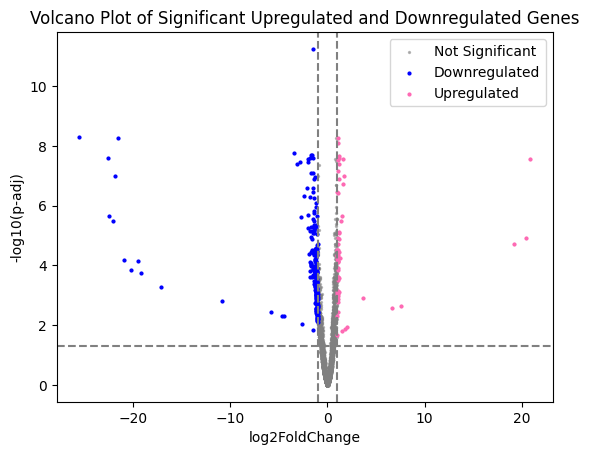

In [77]:
#| echo: false
#| label: fig-1
#| fig-cap: A Volcano plot showing the gene expression changes by significance (-log10(p-adj)) and magnitude (Log2FoldChange) for the A vs B comparison. The horizontal line shows the significance threshold (-log10(0.05) and the two vertical lines indicate the regulation thresholds. 
volcano_plot(Dataset1)

#### Condition E:

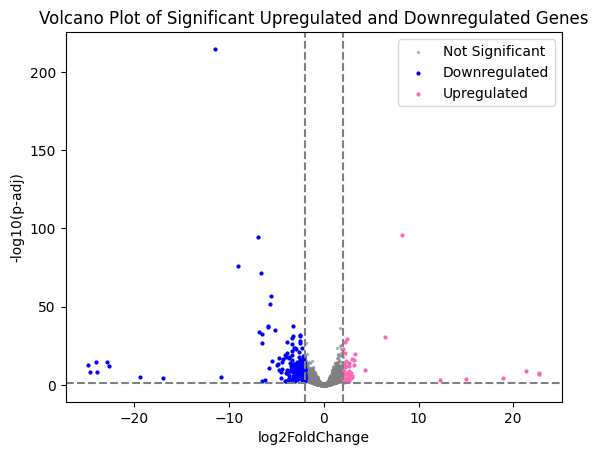

In [73]:
#| echo: false
#| label: fig-2
#| fig-cap: A Volcano plot showing the gene expression changes by significance (-log10(p-adj)) and magnitude (Log2FoldChange) for the A vs E comparison. The horizontal line shows the significance threshold (-log10(0.05) and the two vertical lines indicate the regulation thresholds.
volcano_plot(Dataset2)

In [80]:
#| echo: false
def MA_plot(deseq):
    plt.xscale("log")
    plt.scatter(x=deseq["baseMean"], y=deseq["log2FoldChange"], alpha=0.5, s=1, color="lightseagreen",
                label="Not Significant") #Plot all genes

    down = deseq[(deseq["baseMean"] <= 10000) & (deseq["log2FoldChange"] < -1)]  # Define downregulated genes
    up = deseq[(deseq["baseMean"] <= 10000) & (deseq["log2FoldChange"] > 1)] #Define upregulated genes

    plt.scatter(x=down["baseMean"], y=down["log2FoldChange"], s=1, color="darkorange",
                label="Downregulated")  # Plot downregulated genes
    plt.scatter(x=up["baseMean"], y=up["log2FoldChange"], s=1, color="hotpink", label="Upregulated") #Plot upregulated genes
    plt.xlabel("log(Base Mean)")
    plt.ylabel("log2FC")
    plt.axhline(y=0, color="black", linewidth=0.5) #Add in y = 0 line
    plt.legend()
    plt.title("MA Plot of logFC and BaseMean")
    plt.show()

#### Condition B:

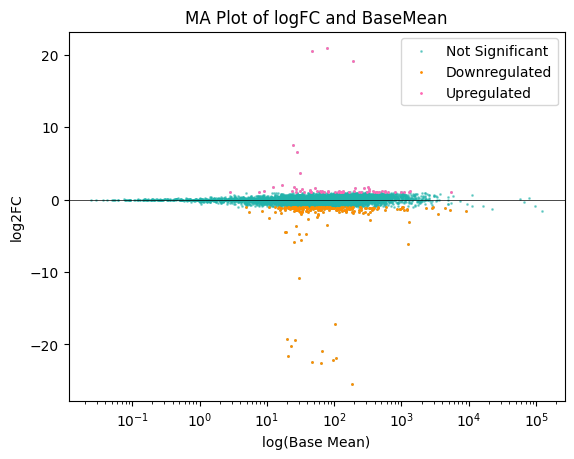

In [81]:
#| echo: false
#| label: fig-3
#| fig-cap: An MA plot showing the relationship between the log fold change and the mean expression for the A vs B comparison.
MA_plot(Dataset1)

#### Condition E:

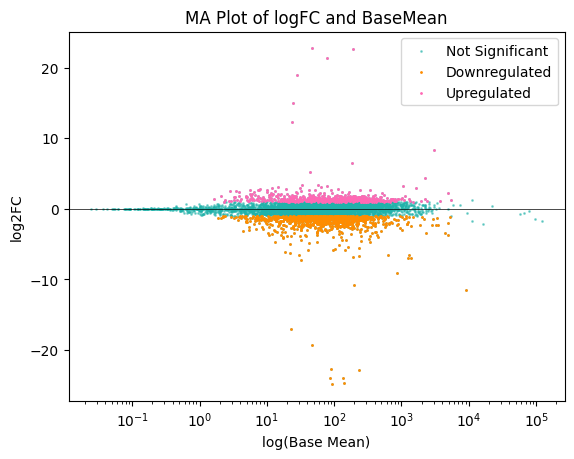

In [82]:
#| echo: false
#| label: fig-4
#| fig-cap: An MA plot showing the relationship between the log fold change and the mean expression for the A vs E comparison.
MA_plot(Dataset2)

In [28]:
#| echo: false
def histo_gene(deseq):
    plt.hist(deseq["pvalue"], bins=50, color="hotpink")
    plt.xlabel("P-value")
    plt.ylabel("Frequency")
    plt.title("Histogram of P-value")
    plt.show()

#### Condition B:

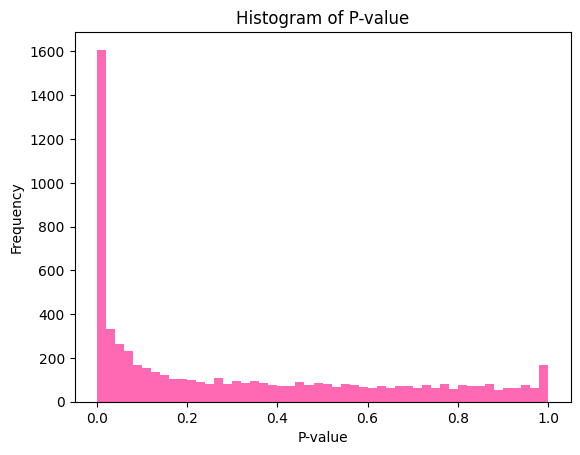

In [29]:
#| echo: false
#| label: fig-5
#| fig-cap: A histogram shwoing the distribution of significantly diffeentialy expressed genes for the A vs B comparison
histo_gene(Dataset1)

#### Condition E:

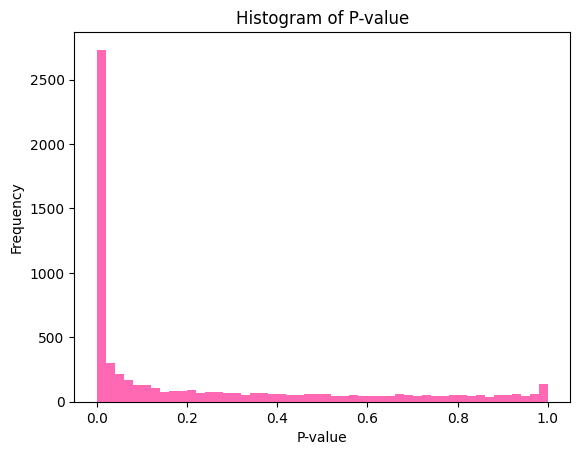

In [30]:
#| echo: false
#| label: fig-6
#| fig-cap: A histogram showing the distribution of significantly diffeentialy expressed genes for the A vs E comparison.
histo_gene(Dataset2)

In [110]:
#| echo: false
def merge_heatmap(data1, data2):
    data1["dataset"] = "B" #Add column identifying dataset origin
    data2["dataset"] = "E"
    comps = pd.concat([data1, data2]) #concatenate new dataframes
    comps_filtered = comps.dropna()  # Remove missing values
    signif_comps = comps_filtered.query("pvalue < 0.05")  # Significant differentially expressed
    # Identify top differentially expressed genes
    top_upreg = signif_comps.query("log2FoldChange > 15")
    top_downreg = signif_comps.query("log2FoldChange < -15")
    top_diff = pd.concat([top_upreg, top_downreg])
    # Select all top differentially expressed gene IDs present in concatenated dataset
    diff_gene = comps[comps["gene_id"].isin(top_diff["gene_id"])]
    heat = diff_gene.pivot(index="gene_id", columns="dataset", values="log2FoldChange") #pivot dataframe
    sns.heatmap(heat, cmap="crest").set(title="Heatmap of Top Differentially Expressed Genes") #Seaborn heatmap
    plt.show()

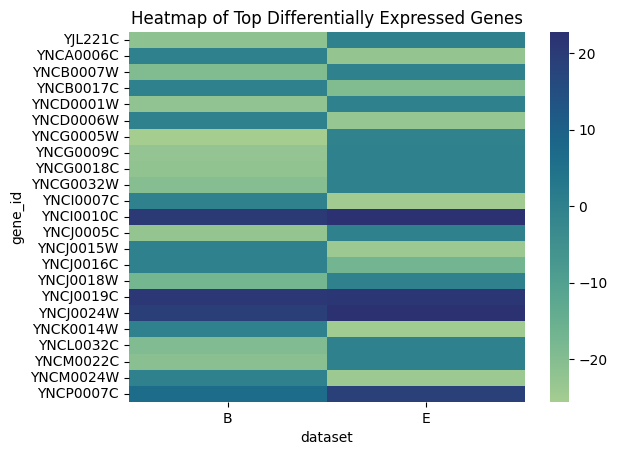

In [111]:
#| echo: false
#| label: fig-7
#| fig-cap: A heatmap showing the log fold change of the top differentially expressed genes from both comparison datasets. Top differentially expressed genes filtered by logFC of >15 or <-15 and P < 0.05.
merge_heatmap(Dataset1, Dataset2)

Genes YNCI0010C, YNCJ0019C and YNCJ0024W were highly upregulated in both condition B and E. Each of these genes encodes a form of tRNA, indicating an increase in protein translation for both conditions. All 3 genes are regulated by transcripton factor FKH2, according to the [Saccharomyces Genome Database](https://www.yeastgenome.org/ ), suggesting a potential FKH2 mutation causing the up-regulation of these three genes.